Optimal LMKAN configuration to match PIKAN (2280 params): width=5, depth=3, K=10, metric_hidden=16
Training PIKAN (Trainable Parameters: 2280) for 10000 epochs...
PIKAN - Epoch 0, Loss: 1.997421
PIKAN - Epoch 500, Loss: 0.000224
PIKAN - Epoch 1000, Loss: 0.000048
PIKAN - Epoch 1500, Loss: 0.000028
PIKAN - Epoch 2000, Loss: 0.000018
PIKAN - Epoch 2500, Loss: 0.000012
PIKAN - Epoch 3000, Loss: 0.000007
PIKAN - Epoch 3500, Loss: 0.000005
PIKAN - Epoch 4000, Loss: 0.000003
PIKAN - Epoch 4500, Loss: 0.000002
PIKAN - Epoch 5000, Loss: 0.000002
PIKAN - Epoch 5500, Loss: 0.000001
PIKAN - Epoch 6000, Loss: 0.000001
PIKAN - Epoch 6500, Loss: 0.000001
PIKAN - Epoch 7000, Loss: 0.000001
PIKAN - Epoch 7500, Loss: 0.000001
PIKAN - Epoch 8000, Loss: 0.000001
PIKAN - Epoch 8500, Loss: 0.000007
PIKAN - Epoch 9000, Loss: 0.000001
PIKAN - Epoch 9500, Loss: 0.000001
PIKAN finished training. Total time: 539.01 seconds.
Training LMKAN (Trainable Parameters: 2136) for 10000 epochs...
LMKAN - Epoch 0, Loss: 2

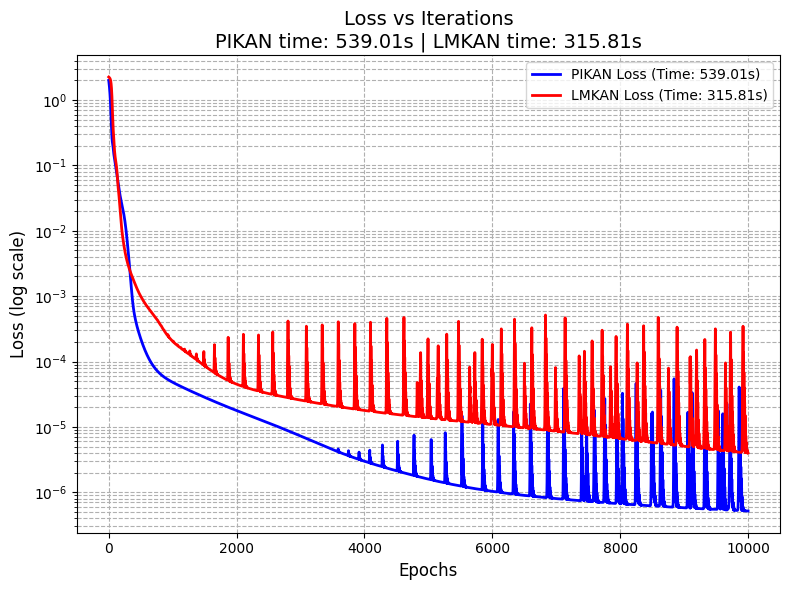

In [ ]:

import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import datetime
import time

import efficientkan
from lm_kan import LMKAN, LMKAN_WIDTH, LMKAN_DEPTH, LMKAN_K, LMKAN_BASIS, LMKAN_GAMMA, LMKAN_METRIC_HIDDEN

# Wrapper for LMKAN to accept (x, t)
class LMKAN_Wrapper(nn.Module):
    def __init__(self, width=LMKAN_WIDTH, depth=LMKAN_DEPTH, K=LMKAN_K, metric_hidden=LMKAN_METRIC_HIDDEN):
        super().__init__()
        self.model = LMKAN(
            in_dim=2,
            width=width,
            depth=depth,
            K=K,
            basis=LMKAN_BASIS,
            gamma=LMKAN_GAMMA,
            metric_hidden=metric_hidden,
        )
    def forward(self, x, t):
        x_t = torch.cat((x, t), dim=1)
        return self.model(x_t)

v = 0.001
N_x = 100
N_t = 100
x = torch.linspace(-1, 1, N_x).view(-1, 1).requires_grad_(True)
t = torch.linspace(0, 1, N_t).view(-1, 1).requires_grad_(True)

x_ic = x.clone().detach().requires_grad_(True)
t_ic = torch.zeros_like(x_ic).requires_grad_(True)
u_ic = 0.53 * x_ic + 0.47 * torch.sin(-1.5 * np.pi * x_ic)

def pinn_loss(model, x, t, u_ic):
    u_pred = model(x, t)
    u_t = torch.autograd.grad(u_pred, t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    
    f_pred = u_t - v * u_xx + u_pred ** 3 - u_pred
    
    x_ic_t_ic = torch.cat((x_ic, t_ic), dim=1)
    ic_pred = model(x_ic, t_ic)
    ic_loss = torch.mean((ic_pred - u_ic) ** 2)

    ones = torch.ones_like(t).requires_grad_(True)
    minus_ones = (-1)*torch.ones_like(t).requires_grad_(True)
    u_t_plus = model(ones, t)
    u_t_minus = model(minus_ones, t)
    L_boundary = torch.mean((u_t_plus - ones) ** 2)
    L_difs = torch.mean((u_t_minus - minus_ones) ** 2)
    
    loss = torch.mean(f_pred ** 2) + L_boundary + ic_loss + L_difs
    return loss, f_pred

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, name, num_epochs=1000):
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    loss_list = []
    epochs_list = []
    
    param_count = count_parameters(model)
    print(f"Training {name} (Trainable Parameters: {param_count}) for {num_epochs} epochs...")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss, _ = pinn_loss(model, x, t, u_ic)
        loss.backward(retain_graph=True)
        optimizer.step()
        loss_list.append(loss.item())
        epochs_list.append(epoch)
        if epoch % 500 == 0:
            print(f'{name} - Epoch {epoch}, Loss: {loss.item():.6f}')
            
    end_time = time.time()
    train_time = end_time - start_time
    print(f"{name} finished training. Total time: {train_time:.2f} seconds.")
    return loss_list, epochs_list, train_time

# Setup models
pikan_model = efficientkan.KAN_twovariable([2,12,8,12,1])
pikan_params = count_parameters(pikan_model)

# Auto-tune LMKAN parameters to closely match PIKAN's parameter count
best_diff = float('inf')
best_config = None
for w in [5, 8, 12, 16, 20]:
    for d in [2, 3, 4]:
        for k in [7, 10, 15]:
            for mh in [16, 32, 64]:
                test_lmkan = LMKAN_Wrapper(width=w, depth=d, K=k, metric_hidden=mh)
                lmkan_params = count_parameters(test_lmkan)
                if abs(lmkan_params - pikan_params) < best_diff:
                    best_diff = abs(lmkan_params - pikan_params)
                    best_config = (w, d, k, mh)

print(f"Optimal LMKAN configuration to match PIKAN ({pikan_params} params): width={best_config[0]}, depth={best_config[1]}, K={best_config[2]}, metric_hidden={best_config[3]}")
lmkan_model = LMKAN_Wrapper(width=best_config[0], depth=best_config[1], K=best_config[2], metric_hidden=best_config[3])

pikan_loss, epochs, pikan_time = train_model(pikan_model, "PIKAN", num_epochs=10000)
lmkan_loss, _, lmkan_time = train_model(lmkan_model, "LMKAN", num_epochs=10000)

# Plot Loss Comparison
plt.figure(figsize=(8, 6))
plt.plot(epochs, pikan_loss, label=f'PIKAN Loss (Time: {pikan_time:.2f}s)', color='blue', linewidth=2)
plt.plot(epochs, lmkan_loss, label=f'LMKAN Loss (Time: {lmkan_time:.2f}s)', color='red', linewidth=2)
plt.yscale('log')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (log scale)', fontsize=12)
plt.title(f'Loss vs Iterations\nPIKAN time: {pikan_time:.2f}s | LMKAN time: {lmkan_time:.2f}s', fontsize=14)
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.savefig('outputs/loss_comparison.pdf')

# Numerical Solution
L = 1.0     
T = 1.0    
N = 100     
M = 10000    
dx = 2 * L / N
dt = T / M

x_num = np.linspace(-L, L, N+1)
t_num = np.linspace(0, T, M+1)

u_num = np.zeros((M+1, N+1))
u_num[0, :] = 0.53 * x_num + 0.47 * np.sin(-1.5 * np.pi * x_num)
u_num[:, 0] = -1
u_num[:, -1] = 1

for n in range(0, M):
    for i in range(1, N):
        u_num[n+1, i] = u_num[n, i] + dt * ((u_num[n, i+1] - 2*u_num[n, i] + u_num[n, i-1]) / dx**2 + u_num[n, i] - u_num[n, i]**3)

# Predictions at multiple time steps (0.9ms, 1.0ms, 1.5ms)
t_targets = [0.0009, 0.0010, 0.0015]
x_plot = torch.linspace(-1, 1, 1000).view(-1, 1).requires_grad_(True)

for t_val in t_targets:
    k = int(round(t_val / dt))
    t_eval = t_num[k]
    t_plot = torch.full_like(x_plot, t_eval, requires_grad=True)

    u_pred_pikan = pikan_model(x_plot, t_plot)
    u_pred_lmkan = lmkan_model(x_plot, t_plot)

    _, f_pred_pikan = pinn_loss(pikan_model, x_plot, t_plot, u_ic=u_ic)
    _, f_pred_lmkan = pinn_loss(lmkan_model, x_plot, t_plot, u_ic=u_ic)

    f_pred_pikan = f_pred_pikan.detach().numpy()
    f_pred_lmkan = f_pred_lmkan.detach().numpy()

    u_pred_pikan = u_pred_pikan.detach().numpy()
    u_pred_lmkan = u_pred_lmkan.detach().numpy()
    
    t_ms_str = f"{t_eval * 1000:g} ms"

    # Solution Plot (Standalone)
    plt.figure(figsize=(10, 4))
    plt.plot(x_plot.detach().numpy(), u_pred_pikan, label=f'PIKAN {t_ms_str}', color="blue", linestyle='-', linewidth=2)
    plt.plot(x_plot.detach().numpy(), u_pred_lmkan, label=f'LMKAN {t_ms_str}', color="red", linestyle='-', linewidth=2)
    plt.plot(x_num[::5], u_num[k, ::5], '--', label=f'Numerical {t_ms_str}', marker="*", markersize=8, color="black")
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('u(x, t)', fontsize=12)
    plt.title(f'Solution of Allen-Cahn Equation at t = {t_ms_str}', fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/solution_{t_ms_str.replace(" ", "_")}.pdf')
    plt.close()

    # Residual Plot (Standalone)
    plt.figure(figsize=(10, 4))
    plt.plot(x_plot.detach().numpy(), f_pred_pikan, label=f'PIKAN Residual {t_ms_str}', color="blue", linestyle='-', linewidth=2)
    plt.plot(x_plot.detach().numpy(), f_pred_lmkan, label=f'LMKAN Residual {t_ms_str}', color="red", linestyle='-', linewidth=2)
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Residual f_pred', fontsize=12)
    plt.title(f'PDE Residual at t = {t_ms_str}', fontsize=14)
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/residual_{t_ms_str.replace(" ", "_")}.pdf')
    plt.close()

# 2D Spatio-Temporal Heatmaps (viridis)
t_grid, x_grid = torch.meshgrid(torch.linspace(0, 1, 100), torch.linspace(-1, 1, 100), indexing='ij')
x_flat = x_grid.reshape(-1, 1).requires_grad_(True)
t_flat = t_grid.reshape(-1, 1).requires_grad_(True)

u_pred_pikan_2d = pikan_model(x_flat, t_flat).detach().numpy().reshape(100, 100)
u_pred_lmkan_2d = lmkan_model(x_flat, t_flat).detach().numpy().reshape(100, 100)

u_num_2d = u_num[::100, :-1] # downsample numerical time to 100 steps to match spatial sizing

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Numerical
im0 = axes[0].pcolormesh(x_num[:-1], t_num[::100], u_num_2d, cmap='viridis', shading='auto')
axes[0].set_title('Numerical', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label('u(x,t)')

# Plot PIKAN
im1 = axes[1].pcolormesh(x_grid[0].numpy(), t_grid[:,0].numpy(), u_pred_pikan_2d, cmap='viridis', shading='auto')
axes[1].set_title('PIKAN', fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label('u(x,t)')

# Plot LM-KAN
im2 = axes[2].pcolormesh(x_grid[0].numpy(), t_grid[:,0].numpy(), u_pred_lmkan_2d, cmap='viridis', shading='auto')
axes[2].set_title('LM-KAN (rbf)', fontweight='bold')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
cbar2 = fig.colorbar(im2, ax=axes[2])
cbar2.set_label('u(x,t)')

plt.tight_layout()
plt.savefig('outputs/spatio_temporal_heatmaps.pdf')
plt.close()

print("All plots saved successfully.")
